In [1]:
%matplotlib inline

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import random
import math
from torch.utils.data import TensorDataset, DataLoader
from FrEIA.framework import InputNode, OutputNode, Node, ReversibleGraphNet
from FrEIA.modules import GLOWCouplingBlock, PermuteRandom
import os

import torch.optim as optim
from geomloss import SamplesLoss

In [3]:

PATH = os.path.join(os.getcwd(),'data')
log_PATH = os.path.join(os.getcwd(), "logs")

divergence = "KLD" # GAN, JSD, RKL, KLD 
modelName = "f-GAN-"+ divergence
batch_size = 512
workers = 2
epochs = 20
data_dim = 1
latent_dim = 1
gf_dim = 64
df_dim = 64
zero_noise_scale = 5e-2
in_h = 64
in_w =64
c_dim = 1
approx_wasserstein = SamplesLoss(loss="sinkhorn", p=2, blur=0.05)
TINY = 1e-6
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

manualSeed = 3432


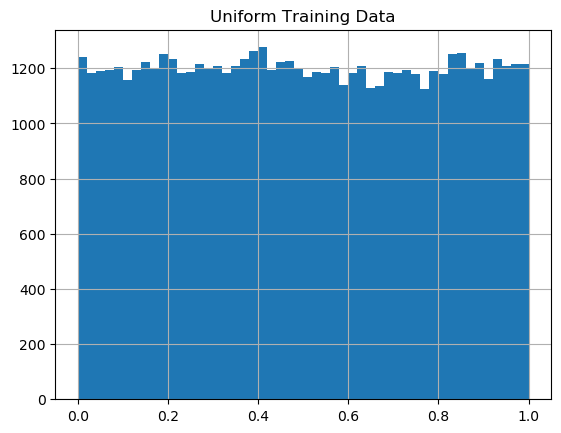

In [4]:

def make_1d_uniform_dataset(n_samples=60000, low=0, high=1):
    # Sample uniformly in [low, high]
    data = (high - low) * torch.rand(n_samples, 1) + low
    # Split into train and validation sets
    n_train = int(n_samples * (1 - 0.2))
    train_data, val_data = data[:n_train], data[n_train:]
    labels = torch.zeros(n_samples, 1)  # Dummy labels
    train_labels, val_labels = labels[:n_train], labels[n_train:]

    # Create TensorDatasets for train and validation
    train_set = TensorDataset(train_data, train_labels)
    val_set = TensorDataset(val_data, val_labels)
    
    # Dummy labels for compatibility
    labels = torch.zeros(n_samples)
    
    # Plot histogram
    plt.hist(data.numpy(), bins=50)
    plt.title("Uniform Training Data")
    plt.grid(True)
    plt.show()

    return train_set, val_set

train_set, val_set = make_1d_uniform_dataset()
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)



In [5]:

# Define subnet (MLP used inside coupling blocks)
def subnet_fc(c_in, c_out, hidden_units):
    return nn.Sequential(
        nn.Linear(c_in, hidden_units),
        nn.ReLU(),
        nn.Linear(hidden_units, c_out)
    )

# Build the INN using GLOW-style blocks
def get_inn(dim_tot, hidden_units=128, num_layers=4):
    nodes = [InputNode(dim_tot, name='input')]
    for k in range(num_layers):
        nodes.append(Node(
            nodes[-1],
            GLOWCouplingBlock,
            {'subnet_constructor': lambda c_in, c_out: subnet_fc(c_in, c_out, hidden_units),
             'clamp': 2.0},
            name=f'coupling_{k}'))
        nodes.append(Node(
            nodes[-1],
            PermuteRandom,
            {'seed': k},
            name=f'permute_{k}'))
    nodes.append(OutputNode(nodes[-1], name='output'))
    
    model = ReversibleGraphNet(nodes, verbose=False)
    for param in model.parameters():
        if param.requires_grad:
            if param.dim() > 1:
                nn.init.orthogonal_(param, gain=0.8)
            else:
                nn.init.constant_(param, 0.0)
    return model


class Q(nn.Module):
    def __init__(self, ndim=latent_dim, hidden_units=64, num_layers=6):
        super().__init__()
        self.model = get_inn(ndim, hidden_units=hidden_units, num_layers=num_layers)

    def forward(self, z, rev=False):
        out, _ = self.model(z, rev=rev)
        return out


In [6]:

class V(nn.Module):
    def __init__(self, hidden_dim=64):
        super(V, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(data_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)  # Output is scalar score
        )

    def forward(self, x):
        return self.model(x)


In [7]:

class Activation_g(nn.Module):
  def __init__(self,divergence="GAN"):
    super(Activation_g,self).__init__()
    self.divergence =divergence
  def forward(self,v):
    divergence = self.divergence
    if divergence == "KLD":
      return v
    elif divergence == "RKL":
      return -torch.exp(-v)
    elif divergence == "CHI":
      return v
    elif divergence == "SQH":
      return 1-torch.exp(-v)
    elif divergence == "JSD":
      return torch.log(torch.tensor(2.))-torch.log(1.0+torch.exp(-v))
    elif divergence == "GAN":
      return -torch.log(1.0+torch.exp(-v)) # log sigmoid

In [8]:

class Conjugate_f(nn.Module):
  def __init__(self,divergence="GAN"):
    super(Conjugate_f,self).__init__()
    self.divergence = divergence
  def forward(self,t):
    divergence= self.divergence
    if divergence == "KLD":
      return torch.exp(t-1)
    elif divergence == "RKL":
      return -1 -torch.log(-t)
    elif divergence == "CHI":
      return 0.25*t**2+t
    elif divergence == "SQH":
      return t/(torch.tensor(1.)-t)
    elif divergence == "JSD":
      return -torch.log(2.0-torch.exp(t))
    elif divergence == "GAN":
      return  -torch.log(1.0-torch.exp(t))

In [9]:

class VLOSS(nn.Module):
  def __init__(self,divergence="GAN"):
    super(VLOSS,self).__init__()
    self.activation = Activation_g(divergence)
  def forward(self,v):
    return torch.mean(self.activation(v))

In [10]:

class QLOSS(nn.Module):
  def __init__(self,divergence="GAN"):
    super(QLOSS,self).__init__()
    self.conjugate = Conjugate_f(divergence)
    self.activation = Activation_g(divergence)
  def forward(self,v):
    return torch.mean(-self.conjugate(self.activation(v)))

In [11]:
Q_net = Q().to(device)
V_net = V().to(device)

Q_criterion =QLOSS(divergence)
V_criterion =VLOSS(divergence)

Q_optimizer = optim.Adam(Q_net.parameters(),lr=2e-4,betas=(0.5,0.9))
V_optimizer = optim.Adam(V_net.parameters(),lr=2e-4,betas=(0.5,0.9))


/home/ananya-acharya/miniconda3/envs/cINN/lib/python3.11/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


In [12]:

Q_losses = []
V_losses = []

iter_per_plot = 250
plot_per_eps=(int(len(train_loader)/iter_per_plot)+1)



In [13]:
# Training loop with 10 runs for averaging
disp_values = [0, 3, 5, 10, 15, 20, 25]
divergence_types = ['sinkhorn', 'KLD']
num_runs = 10

# Store samples and MMD values from all runs
all_samples = {}  # Key: (div_type, disp, run_idx)
mmd_values = {}   # Key: (div_type, disp) -> list of MMD values

for div_type in divergence_types:
    for disp in disp_values:
        mmd_values[(div_type, disp)] = []
        
        for run in range(num_runs):
            print(f"\n{'='*60}")
            print(f"Run {run+1}/{num_runs} - Divergence: {div_type}, Displacement: {disp}")
            print(f"{'='*60}\n")
            
            # Set different random seed for each run
            run_seed = manualSeed + run * 100
            torch.manual_seed(run_seed)
            np.random.seed(run_seed)
            
            # Initialize new Q model for this configuration
            Q_net = Q().to(device)
            Q_optimizer = optim.Adam(Q_net.parameters(), lr=2e-4, betas=(0.5, 0.9))
            
            if div_type == 'KLD':
                # Initialize V network for KLD training
                V_net = V().to(device)
                V_optimizer = optim.Adam(V_net.parameters(), lr=2e-4, betas=(0.5, 0.9))
                Q_criterion = QLOSS('KLD')
                V_criterion = VLOSS('KLD')
            
            # Training loop
            for ep in range(epochs):
                for i, (data, _) in enumerate(train_loader):
                    b_size = data.shape[0]
                    data = data.to(torch.float32).to(device)
                    
                    if div_type == 'sinkhorn':
                        # Train with Sinkhorn divergence
                        z = torch.rand(b_size, latent_dim).to(device) + disp
                        Q_net.zero_grad()
                        pad_x = zero_noise_scale * torch.randn(b_size, latent_dim - data_dim, device=device)
                        x = torch.cat([data, pad_x], dim=1)
                        x_samples = Q_net(z, rev=True)
                        loss = approx_wasserstein(x, x_samples)
                        loss.backward()
                        Q_optimizer.step()
                        
                    else:  # KLD
                        # Train V
                        V_net.zero_grad()
                        v = V_net(data)
                        v = torch.clamp(v, min=-4.0, max=4.0)
                        loss_real = -V_criterion(v)
                        loss_real.backward(retain_graph=True)
                        
                        z = torch.rand(b_size, latent_dim).to(device) + disp
                        fake_data = Q_net(z, rev=True)[:, :data_dim].unsqueeze(1)
                        v_fake = V_net(fake_data.detach())
                        v_fake = torch.clamp(v_fake, min=-4.0, max=4.0)
                        
                        loss_fake = -Q_criterion(v_fake)
                        loss_fake.backward()
                        loss_V = -(loss_real + loss_fake)
                        V_optimizer.step()
                        
                        # Train Q
                        Q_net.zero_grad()
                        v_fake = V_net(fake_data)
                        loss_Q = -V_criterion(v_fake)
                        loss_Q.backward()
                        Q_optimizer.step()
                    
                    if (i+1) % iter_per_plot == 0 or i == 0:
                        print(f'Epoch [{ep}/{epochs}], Step [{i+1}/{len(train_loader)}]')
            
            # Generate samples for this run
            z_test = torch.rand(12000, latent_dim).to(device) + disp
            with torch.no_grad():
                samples = Q_net(z_test, rev=True)[:, :data_dim]
            samples_np = samples.cpu().numpy()
            
            # Store samples
            all_samples[(div_type, disp, run)] = samples_np
            
            # Calculate MMD for this run
            from loss_functions import MMD_multiscale
            ground_truth = val_set.tensors[0].to(device)
            mmd = MMD_multiscale(samples, ground_truth).item()
            mmd_values[(div_type, disp)].append(mmd)
            
            print(f"\nCompleted run {run+1}/{num_runs} for {div_type}, disp={disp}")
            print(f"MMD for this run: {mmd:.6f}")

print("\n" + "="*60)
print("Training completed for all configurations and runs!")
print("="*60)


Run 1/10 - Divergence: sinkhorn, Displacement: 0



/home/ananya-acharya/miniconda3/envs/cINN/lib/python3.11/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Epoch [0/20], Step [1/94]
Epoch [1/20], Step [1/94]
Epoch [2/20], Step [1/94]
Epoch [3/20], Step [1/94]
Epoch [4/20], Step [1/94]
Epoch [5/20], Step [1/94]
Epoch [6/20], Step [1/94]
Epoch [7/20], Step [1/94]
Epoch [8/20], Step [1/94]
Epoch [9/20], Step [1/94]
Epoch [10/20], Step [1/94]
Epoch [11/20], Step [1/94]
Epoch [12/20], Step [1/94]
Epoch [13/20], Step [1/94]
Epoch [14/20], Step [1/94]
Epoch [15/20], Step [1/94]
Epoch [16/20], Step [1/94]
Epoch [17/20], Step [1/94]
Epoch [18/20], Step [1/94]
Epoch [19/20], Step [1/94]

Completed run 1/10 for sinkhorn, disp=0
MMD for this run: 0.000837

Run 2/10 - Divergence: sinkhorn, Displacement: 0

Epoch [0/20], Step [1/94]
Epoch [1/20], Step [1/94]
Epoch [2/20], Step [1/94]
Epoch [3/20], Step [1/94]
Epoch [4/20], Step [1/94]
Epoch [5/20], Step [1/94]
Epoch [6/20], Step [1/94]
Epoch [7/20], Step [1/94]
Epoch [8/20], Step [1/94]
Epoch [9/20], Step [1/94]
Epoch [10/20], Step [1/94]
Epoch [11/20], Step [1/94]
Epoch [12/20], Step [1/94]
Epoch [13/

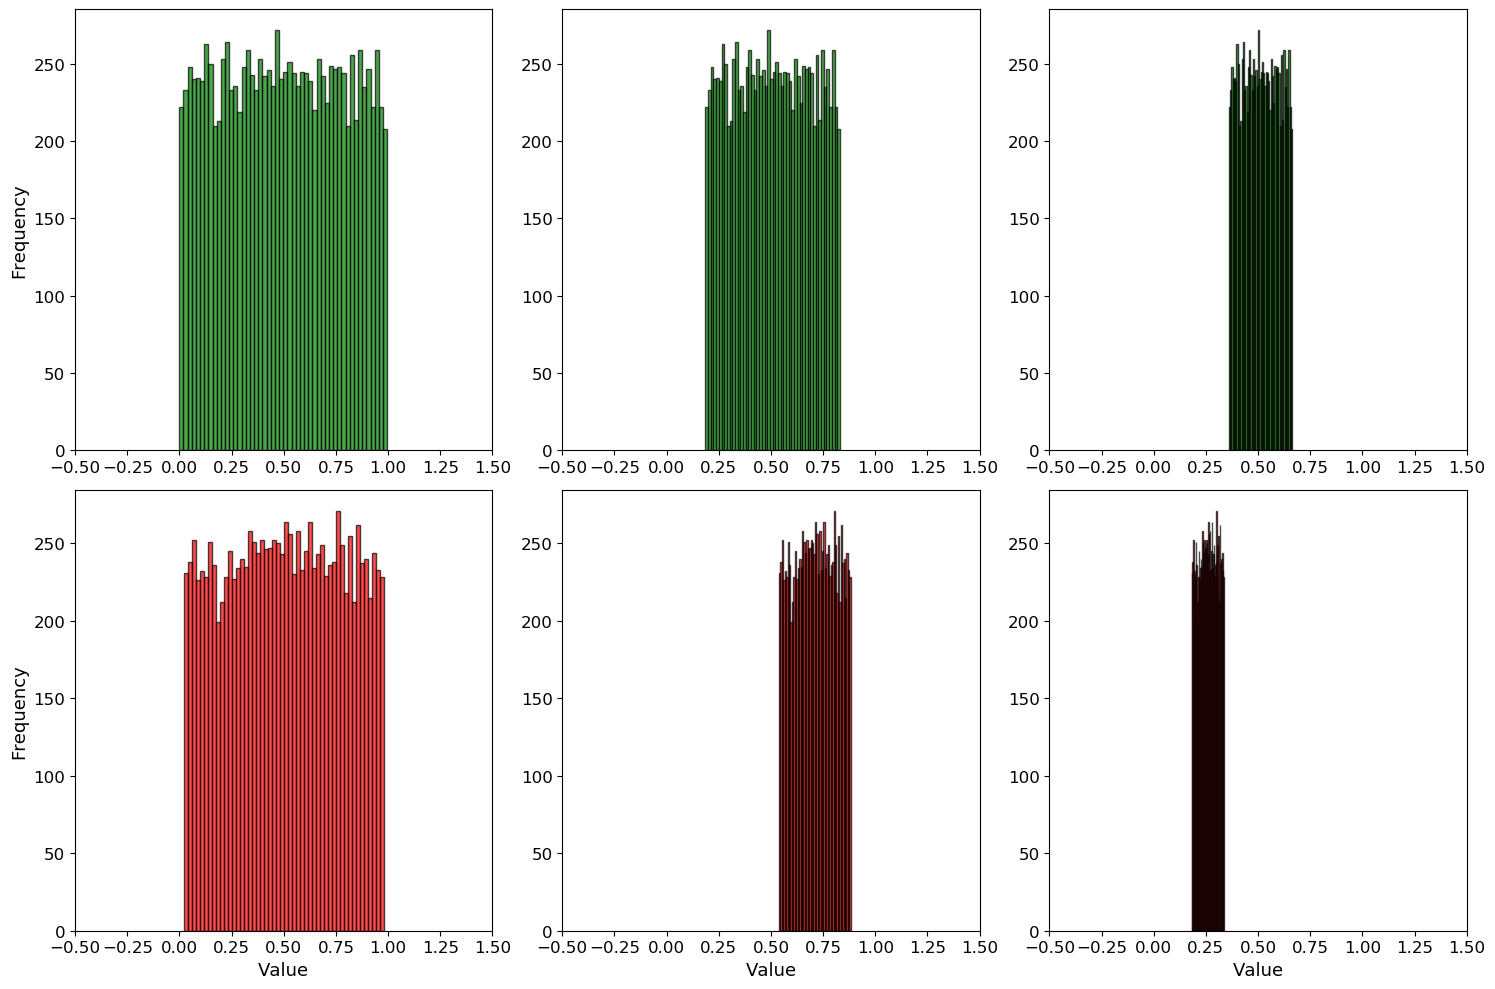

In [14]:
# Create 2x3 figure comparing Sinkhorn (top row, green) vs KLD (bottom row, red)
import tikzplotlib

# Only use first 3 displacement values [0, 3, 5]
disp_values_to_plot = disp_values[:3]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Top row: Sinkhorn divergence (green)
for disp_idx, disp in enumerate(disp_values_to_plot):
    ax = axes[0, disp_idx]
    samples_np = all_samples[('sinkhorn', disp, 0)]
    ax.hist(samples_np, bins=50, color='green', edgecolor='black', alpha=0.7)
    ax.set_xlim(-0.5, 1.5)
    ax.tick_params(labelsize=12)
    
    if disp_idx == 0:
        ax.set_ylabel('Frequency', fontsize=13)

# Bottom row: KLD (red)
for disp_idx, disp in enumerate(disp_values_to_plot):
    ax = axes[1, disp_idx]
    samples_np = all_samples[('KLD', disp, 0)]
    ax.hist(samples_np, bins=50, color='red', edgecolor='black', alpha=0.7)
    ax.set_xlim(-0.5, 1.5)
    ax.tick_params(labelsize=12)
    ax.set_xlabel('Value', fontsize=13)
    
    if disp_idx == 0:
        ax.set_ylabel('Frequency', fontsize=13)

plt.tight_layout()
tikzplotlib.save('obs6_comparison.tex')
#plt.savefig('obs6_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# Create table with averaged MMD values across 10 runs
import pandas as pd

mmd_table_data = []

for disp in disp_values:
    row = {'Displacement': disp}
    
    # Calculate mean and std for KLD
    kld_mmds = mmd_values[('KLD', disp)]
    kld_mean = np.mean(kld_mmds)
    kld_std = np.std(kld_mmds)
    row['KL Divergence'] = f"{kld_mean:.2e} ± {kld_std:.2e}"
    
    # Calculate mean and std for Sinkhorn
    sinkhorn_mmds = mmd_values[('sinkhorn', disp)]
    sinkhorn_mean = np.mean(sinkhorn_mmds)
    sinkhorn_std = np.std(sinkhorn_mmds)
    row['Sinkhorn Divergence'] = f"{sinkhorn_mean:.2e} ± {sinkhorn_std:.2e}"
    
    mmd_table_data.append(row)

# Create DataFrame
df_mmd = pd.DataFrame(mmd_table_data)

# Display table
print("\n" + "="*80)
print("MMD between samples from true distribution U(0,1) and generated samples")
print("Values shown as: Mean ± Std (averaged over 10 runs)")
print("="*80)
print(df_mmd.to_string(index=False))
print("="*80)

# Save to file
df_mmd.to_csv('obs6_mmd_table.csv', index=False)
print("\nTable saved as 'obs6_mmd_table.csv'")

# Also create a numeric version for further analysis
mmd_numeric = []
for disp in disp_values:
    row = {
        'Displacement': disp,
        'KLD_mean': np.mean(mmd_values[('KLD', disp)]),
        'KLD_std': np.std(mmd_values[('KLD', disp)]),
        'Sinkhorn_mean': np.mean(mmd_values[('sinkhorn', disp)]),
        'Sinkhorn_std': np.std(mmd_values[('sinkhorn', disp)])
    }
    mmd_numeric.append(row)

df_numeric = pd.DataFrame(mmd_numeric)
print("\nNumeric values:")
print(df_numeric.to_string(index=False))


MMD between samples from true distribution U(0,1) and generated samples
Values shown as: Mean ± Std (averaged over 10 runs)
 Displacement       KL Divergence Sinkhorn Divergence
            0 3.07e-03 ± 2.10e-03 1.35e-03 ± 6.87e-04
            3 1.23e+00 ± 5.17e-01 2.40e-01 ± 4.77e-03
            5 1.36e+00 ± 1.57e-01 9.13e-01 ± 3.35e-03
           10 3.07e+00 ± 1.28e-01 1.28e+00 ± 7.92e-04
           15 1.43e+00 ± 3.37e-02 1.33e+00 ± 6.48e-04
           20 1.69e+00 ± 1.23e-01 2.28e+00 ± 1.23e-03
           25 3.73e+00 ± 3.67e-01 4.96e+00 ± 1.37e-03

Table saved as 'obs6_mmd_table.csv'

Numeric values:
 Displacement  KLD_mean  KLD_std  Sinkhorn_mean  Sinkhorn_std
            0  0.003072 0.002104       0.001349      0.000687
            3  1.225036 0.516754       0.240423      0.004772
            5  1.358620 0.157242       0.912703      0.003354
           10  3.070125 0.127931       1.281408      0.000792
           15  1.430241 0.033712       1.331814      0.000648
           20  1.